# Crea eval set bilanciato

Questo notebook costruisce un dataset di valutazione bilanciato per controllare se il reward model impara bene anche eventi rari, non solo passi `running`.

Il dataset finale viene salvato in:

```text
data_for_training/balanced_eval_dataset.pkl
```

Struttura salvata:

```python
{
    "metadata": {...},
    "segments_by_length": {
        1: [Trajectory(...), ...],
        5: [Trajectory(...), ...],
        20: [Trajectory(...), ...],
    },
    "labels_by_length": {
        1: ["running", "arrived", ...],
        5: [...],
        20: [...],
    },
}
```

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import pickle
import random
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for rel in ["human-feedback-rl", "sumo-rl-ego", "notebooks"]:
    path = str(REPO_ROOT / rel)
    if path not in sys.path:
        sys.path.insert(0, path)

import sumo_rl_ego as sre
from stable_baselines3 import PPO
from human_feedback_rl.common.trajectory_generators import TrajectoryGeneratorFromAgent
from human_feedback_rl.common.types import Trajectory
from loadings import load_reward_ensemble

# Headless SUMO patch usata anche negli altri notebook del progetto.
try:
    import sumo_gym_ego.core.simulation as _sim_mod
    import traci as _traci_mod
    _sim_mod.load_traci = lambda use_gui: _traci_mod
except Exception as exc:
    print(f"SUMO headless patch non applicata: {exc}")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 130

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)
random.seed(RNG_SEED)

EXPERIMENT_ROOT = REPO_ROOT / "outputs" / "reward_label_experiments" / "20260610_092001"
SAVE_PATH = REPO_ROOT / "data_for_training" / "balanced_eval_dataset.pkl"

# Usa di default il checkpoint finale. Cambia a "checkpoint_0050" se vuoi policy meno mature.
CHECKPOINT_NAME = "checkpoint_0100"

# Per iniziare tieni numeri moderati. Se alcune classi sono scarse, aumenta N_STEPS_PER_AGENT o aggiungi agenti.
N_STEPS_PER_AGENT = 30_000
N_PER_CLASS = 500
SEGMENT_LENGTHS = [1, 5, 20]
TARGET_CLASSES = ["running", "arrived", "collision", "offroad", "timeout"]

# Se None usa tutte le run finali trovate. Puoi filtrare per velocizzare.
# Esempio: SELECT_FAMILIES = ["soft", "binary"]
SELECT_FAMILIES = None
MAX_RUNS_PER_FAMILY = None  # esempio: 5

print("Repo:", REPO_ROOT)
print("Experiment root:", EXPERIMENT_ROOT)
print("Save path:", SAVE_PATH)

Repo: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl
Experiment root: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/20260610_092001
Save path: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/data_for_training/balanced_eval_dataset.pkl


## Trova checkpoint agenti

Usiamo `agent.zip` per generare rollout e `reward_model.pt` solo perché `TrajectoryGeneratorFromAgent` richiede un reward model wrapper. Le transizioni salvate mantengono comunque la reward vera dell'ambiente.

In [2]:
def parse_run_metadata(run_dir: Path):
    name = run_dir.name
    label_match = re.search(r"ppo_chri_([^ ]+)", name)
    q_match = re.search(r"q=(\d+)", name)
    temp_match = re.search(r"temp=([0-9.]+)", name)
    seed_match = re.search(r"seed=(\d+)", name)

    labels_type = label_match.group(1) if label_match else "unknown"
    labels_type = labels_type.replace("binary_bernulli", "binary_bernoulli")
    if labels_type == "binary":
        family = "binary"
    elif labels_type == "binary_bernoulli":
        family = "bernoulli"
    elif labels_type == "soft":
        family = "soft"
    else:
        family = labels_type

    return {
        "run_name": name,
        "label_family": family,
        "labels_type": labels_type,
        "total_queries": int(q_match.group(1)) if q_match else np.nan,
        "temperature": float(temp_match.group(1)) if temp_match else np.nan,
        "seed": int(seed_match.group(1)) if seed_match else np.nan,
    }


def find_agent_checkpoints(root: Path, checkpoint_name: str):
    rows = []
    for ckpt in sorted(root.glob(f"*/{checkpoint_name}")):
        agent_path = ckpt / "agent.zip"
        reward_path = ckpt / "reward_model.pt"
        if not agent_path.exists() or not reward_path.exists():
            continue
        run_dir = ckpt.parent
        rows.append({
            **parse_run_metadata(run_dir),
            "run_dir": run_dir,
            "checkpoint_dir": ckpt,
            "agent_path": agent_path,
            "reward_model_path": reward_path,
        })
    return pd.DataFrame(rows)


ckpt_table = find_agent_checkpoints(EXPERIMENT_ROOT, CHECKPOINT_NAME)
if ckpt_table.empty:
    raise FileNotFoundError(f"Nessun {CHECKPOINT_NAME}/agent.zip trovato sotto {EXPERIMENT_ROOT}")

if SELECT_FAMILIES is not None:
    ckpt_table = ckpt_table[ckpt_table["label_family"].isin(SELECT_FAMILIES)].copy()

if MAX_RUNS_PER_FAMILY is not None:
    ckpt_table = (
        ckpt_table
        .sort_values(["label_family", "total_queries", "temperature", "seed"])
        .groupby("label_family", group_keys=False)
        .head(MAX_RUNS_PER_FAMILY)
        .copy()
    )

ckpt_table = ckpt_table.sort_values(["label_family", "total_queries", "temperature", "seed"])
print(f"Checkpoint selezionati: {len(ckpt_table)}")
ckpt_table[["label_family", "total_queries", "temperature", "seed", "checkpoint_dir"]]

Checkpoint selezionati: 30


,label_family,total_queries,temperature,seed,checkpoint_dir
6,bernoulli,10000,20.0,0,/Users/andreazhang/Desktop/newTesi/sumo-human-...
7,bernoulli,10000,20.0,1,/Users/andreazhang/Desktop/newTesi/sumo-human-...
8,bernoulli,10000,20.0,2,/Users/andreazhang/Desktop/newTesi/sumo-human-...
12,bernoulli,50000,20.0,0,/Users/andreazhang/Desktop/newTesi/sumo-human-...
13,bernoulli,50000,20.0,1,/Users/andreazhang/Desktop/newTesi/sumo-human-...
14,bernoulli,50000,20.0,2,/Users/andreazhang/Desktop/newTesi/sumo-human-...
9,bernoulli,100000,20.0,0,/Users/andreazhang/Desktop/newTesi/sumo-human-...
10,bernoulli,100000,20.0,1,/Users/andreazhang/Desktop/newTesi/sumo-human-...
11,bernoulli,100000,20.0,2,/Users/andreazhang/Desktop/newTesi/sumo-human-...
0,binary,10000,20.0,0,/Users/andreazhang/Desktop/newTesi/sumo-human-...


## Helper per rollout e segmentazione

Un segmento viene classificato usando lo stato dell'ultima transizione del segmento. Per gli stati terminali (`arrived`, `collision`, `offroad`, `timeout`) questo cattura i segmenti che finiscono con quell'evento. Per `running` cattura finestre normali non terminali.

In [3]:
STATUS_NAMES = {
    0: "arrived",
    1: "collision",
    2: "offroad",
    3: "timeout",
    4: "running",
    5: "teleported",
    6: "removed",
}
STATUS_TO_ID = {v: k for k, v in STATUS_NAMES.items()}


def transition_status_name(t):
    if t.next_status is None:
        return "unknown"
    return STATUS_NAMES.get(int(np.argmax(t.next_status)), "unknown")


def segment_status_name(segment):
    return transition_status_name(segment[-1])


def make_env(seed=0, n_envs=1):
    return sre.make_vec_env(
        "HighwayEgo-v0",
        n_envs=n_envs,
        base_seed=seed,
        ego="continuous",
        reward="fast",
    )


def load_generator(checkpoint_row, seed=0):
    env = make_env(seed=seed, n_envs=1)
    reward_model = load_reward_ensemble(
        checkpoint_row.reward_model_path,
        env.observation_space,
        env.action_space,
    )
    agent = PPO.load(checkpoint_row.agent_path, env=env, device="cpu")
    generator = TrajectoryGeneratorFromAgent(agent=agent, reward_model=reward_model, venv=env)
    return generator, env


def collect_trajectories_from_checkpoint(checkpoint_row, steps, seed=0):
    generator, env = load_generator(checkpoint_row, seed=seed)
    try:
        trajectories = list(generator.sample(steps))
    finally:
        try:
            env.close()
        except Exception:
            pass
    return trajectories


def extract_segments_from_trajectory(traj, segment_length):
    """Return overlapping windows of length segment_length from a trajectory."""
    if len(traj) < segment_length:
        return []
    return [Trajectory(traj[i:i + segment_length]) for i in range(0, len(traj) - segment_length + 1)]


def add_trajectory_segments(buckets_by_length, traj, segment_lengths):
    for seg_len in segment_lengths:
        for segment in extract_segments_from_trajectory(traj, seg_len):
            label = segment_status_name(segment)
            if label in TARGET_CLASSES:
                buckets_by_length[seg_len][label].append(segment)


def count_buckets(buckets_by_length):
    rows = []
    for seg_len, buckets in buckets_by_length.items():
        row = {"segment_length": seg_len}
        row.update({label: len(buckets[label]) for label in TARGET_CLASSES})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("segment_length")

## Raccogli segmenti

Questa cella può richiedere tempo, perché fa rollout SUMO. Puoi interromperla e rilanciarla aumentando o riducendo `N_STEPS_PER_AGENT`.

In [4]:
all_trajectories = []

buckets_by_length = {
    seg_len: {label: [] for label in TARGET_CLASSES}
    for seg_len in SEGMENT_LENGTHS
}
collection_log = []

t0_all = time.perf_counter()
for idx, row in ckpt_table.reset_index(drop=True).iterrows():
    t0 = time.perf_counter()
    print(
        f"[{idx + 1}/{len(ckpt_table)}] "
        f"{row.label_family} q={row.total_queries} T={row.temperature:g} seed={row.seed}"
    )
    try:
        trajectories = collect_trajectories_from_checkpoint(
            row,
            steps=N_STEPS_PER_AGENT,
            seed=int(row.seed) if not pd.isna(row.seed) else idx,
        )
    except Exception as exc:
        print(f"  ERRORE: {exc}")
        collection_log.append({
            "run_name": row.run_name,
            "status": "error",
            "error": repr(exc),
            "seconds": time.perf_counter() - t0,
        })
        continue

    all_trajectories.extend(trajectories)
    for traj in trajectories:
        add_trajectory_segments(buckets_by_length, traj, SEGMENT_LENGTHS)

    status_counts = Counter(transition_status_name(traj[-1]) for traj in trajectories if len(traj) > 0)
    collection_log.append({
        "run_name": row.run_name,
        "status": "ok",
        "n_trajectories": len(trajectories),
        "n_transitions": sum(len(t) for t in trajectories),
        "episode_status_counts": dict(status_counts),
        "seconds": time.perf_counter() - t0,
    })
    display(count_buckets(buckets_by_length))

print(f"Tempo totale: {(time.perf_counter() - t0_all) / 60:.1f} min")
collection_log_df = pd.DataFrame(collection_log)
collection_log_df

[1/30] bernoulli q=10000 T=20 seed=0
 Retrying in 1 seconds

Environment closed.


,segment_length,running,arrived,collision,offroad,timeout
0,1,29932,67,78,0,0
1,5,29379,67,66,0,0
2,20,27617,67,41,0,0


[2/30] bernoulli q=10000 T=20 seed=1
 Retrying in 1 seconds

Environment closed.


,segment_length,running,arrived,collision,offroad,timeout
0,1,59859,105,319,14,0
1,5,58187,105,287,14,0
2,20,52740,105,222,14,0


[3/30] bernoulli q=10000 T=20 seed=2
 Retrying in 1 seconds

Environment closed.


...

,segment_length,running,arrived,collision,offroad,timeout
0,1,298510,824,1554,35,50
1,5,289315,824,1334,25,50
2,20,259446,824,930,15,50


[11/30] binary q=10000 T=20 seed=1
 Retrying in 1 seconds

Environment closed.


,segment_length,running,arrived,collision,offroad,timeout
0,1,327467,877,2594,36,50
1,5,314448,877,2203,25,50
2,20,273426,877,1472,15,50


[12/30] binary q=10000 T=20 seed=2
 Retrying in 1 seconds
Interrupt signal received, trying to exit gracefully.

Environment closed.


KeyboardInterrupt: 

## Controlla se il bilanciamento è sufficiente

Se qualche classe ha meno di `N_PER_CLASS`, il notebook salva comunque il massimo numero comune disponibile. Per un dataset davvero bilanciato, aumenta `N_STEPS_PER_AGENT` o aggiungi policy più diverse.

,segment_length,running,arrived,collision,offroad,timeout
0,1,889496,3511,7264,1962,50
1,5,848366,3511,5919,128,50
2,20,723187,3511,3790,39,50


Disponibilità minima per classe: {1: 50, 5: 50, 20: 39}
N per classe che verrà salvato: {1: 50, 5: 50, 20: 39}


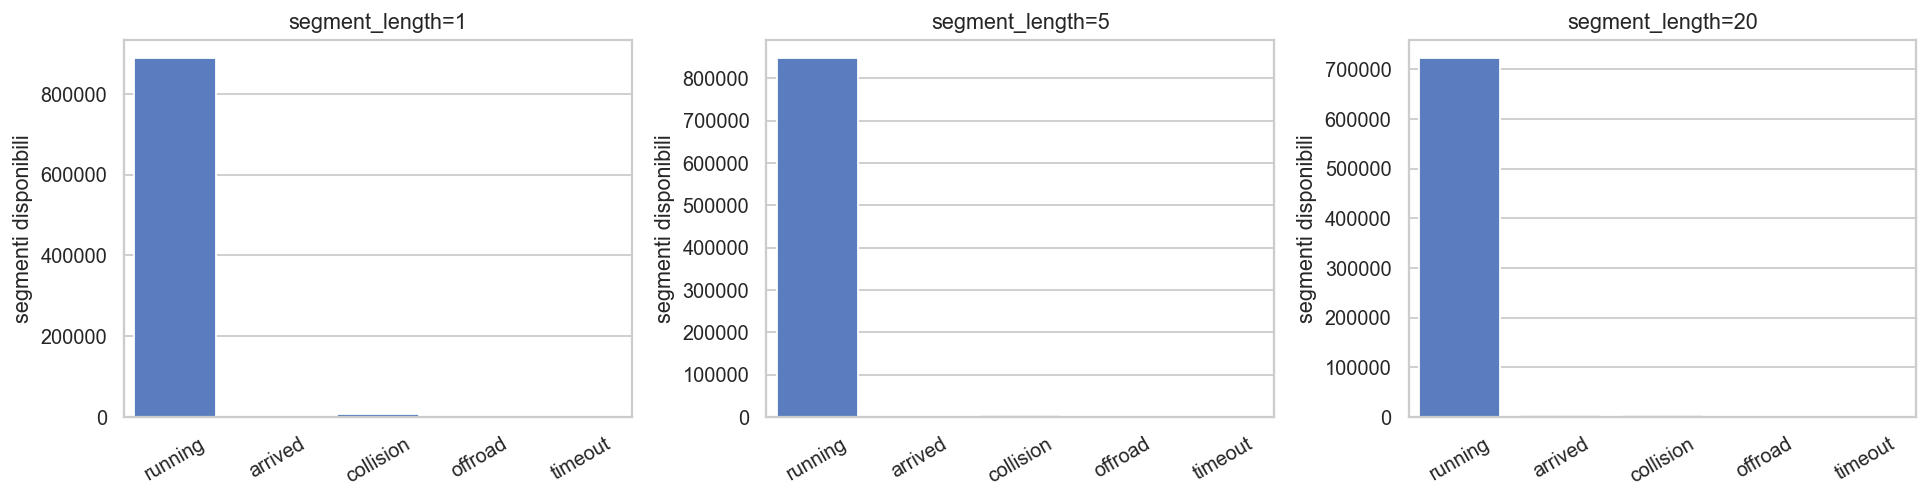

In [5]:
counts = count_buckets(buckets_by_length)
display(counts)

available_per_length = {
    seg_len: min(len(buckets_by_length[seg_len][label]) for label in TARGET_CLASSES)
    for seg_len in SEGMENT_LENGTHS
}
actual_n_per_class = {
    seg_len: min(N_PER_CLASS, available)
    for seg_len, available in available_per_length.items()
}

print("Disponibilità minima per classe:", available_per_length)
print("N per classe che verrà salvato:", actual_n_per_class)

fig, axes = plt.subplots(1, len(SEGMENT_LENGTHS), figsize=(5 * len(SEGMENT_LENGTHS), 4), squeeze=False)
for ax, seg_len in zip(axes.flat, SEGMENT_LENGTHS):
    vals = {label: len(buckets_by_length[seg_len][label]) for label in TARGET_CLASSES}
    sns.barplot(x=list(vals.keys()), y=list(vals.values()), ax=ax)
    ax.axhline(N_PER_CLASS, color="crimson", linestyle="--", linewidth=1, label="target")
    ax.set_title(f"segment_length={seg_len}")
    ax.set_ylabel("segmenti disponibili")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Campiona il dataset bilanciato e salva

Il campionamento è senza replacement dentro ogni bucket. Il dataset finale è mescolato ma mantiene `labels_by_length` allineato ai segmenti.

In [6]:
def sample_balanced_segments(buckets, n_per_class, rng):
    segments = []
    labels = []
    for label in TARGET_CLASSES:
        bucket = buckets[label]
        if len(bucket) < n_per_class:
            raise ValueError(f"Classe {label}: richiesti {n_per_class}, disponibili {len(bucket)}")
        idx = rng.choice(len(bucket), size=n_per_class, replace=False)
        for i in idx:
            segments.append(bucket[int(i)])
            labels.append(label)

    order = rng.permutation(len(segments))
    segments = [segments[int(i)] for i in order]
    labels = [labels[int(i)] for i in order]
    return segments, labels


segments_by_length = {}
labels_by_length = {}
for seg_len in SEGMENT_LENGTHS:
    n = actual_n_per_class[seg_len]
    if n == 0:
        print(f"Skip segment_length={seg_len}: almeno una classe è vuota")
        continue
    segments, labels = sample_balanced_segments(buckets_by_length[seg_len], n, rng)
    segments_by_length[seg_len] = segments
    labels_by_length[seg_len] = labels
    print(f"seg_len={seg_len}: salvati {len(segments)} segmenti ({n} per classe)")

balanced_eval_dataset = {
    "metadata": {
        "created_from": str(EXPERIMENT_ROOT),
        "checkpoint_name": CHECKPOINT_NAME,
        "n_steps_per_agent": N_STEPS_PER_AGENT,
        "requested_n_per_class": N_PER_CLASS,
        "actual_n_per_class": actual_n_per_class,
        "segment_lengths": SEGMENT_LENGTHS,
        "target_classes": TARGET_CLASSES,
        "rng_seed": RNG_SEED,
        "selected_runs": ckpt_table[[
            "run_name", "label_family", "labels_type", "total_queries", "temperature", "seed", "checkpoint_dir"
        ]].astype(str).to_dict(orient="records"),
        "collection_log": collection_log,
    },
    "segments_by_length": segments_by_length,
    "labels_by_length": labels_by_length,
}

SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(SAVE_PATH, "wb") as f:
    pickle.dump(balanced_eval_dataset, f)

print(f"Salvato in: {SAVE_PATH}")

seg_len=1: salvati 250 segmenti (50 per classe)
seg_len=5: salvati 250 segmenti (50 per classe)
seg_len=20: salvati 195 segmenti (39 per classe)
Salvato in: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/data_for_training/balanced_eval_dataset.pkl


## Verifica caricamento

Questa cella ricarica il pickle appena salvato e mostra il bilanciamento finale.

In [7]:
with open(SAVE_PATH, "rb") as f:
    loaded = pickle.load(f)

for seg_len, labels in loaded["labels_by_length"].items():
    print("segment_length", seg_len, Counter(labels))

loaded["metadata"]

segment_length 1 Counter({'collision': 50, 'timeout': 50, 'arrived': 50, 'running': 50, 'offroad': 50})
segment_length 5 Counter({'arrived': 50, 'running': 50, 'timeout': 50, 'offroad': 50, 'collision': 50})
segment_length 20 Counter({'collision': 39, 'timeout': 39, 'arrived': 39, 'running': 39, 'offroad': 39})


{'created_from': '/Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/20260610_092001',
 'checkpoint_name': 'checkpoint_0100',
 'n_steps_per_agent': 30000,
 'requested_n_per_class': 500,
 'actual_n_per_class': {1: 50, 5: 50, 20: 39},
 'segment_lengths': [1, 5, 20],
 'target_classes': ['running', 'arrived', 'collision', 'offroad', 'timeout'],
 'rng_seed': 0,
 'selected_runs': [{'run_name': 'ppo_chri_binary_bernoulli seg=1 q=10000 temp=20 seed=0 bernoulli_10k',
   'label_family': 'bernoulli',
   'labels_type': 'binary_bernoulli',
   'total_queries': '10000',
   'temperature': '20.0',
   'seed': '0',
   'checkpoint_dir': '/Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/20260610_092001/ppo_chri_binary_bernoulli seg=1 q=10000 temp=20 seed=0 bernoulli_10k/checkpoint_0100'},
  {'run_name': 'ppo_chri_binary_bernoulli seg=1 q=10000 temp=20 seed=1 bernoulli_10k',
   'label_family': 'bernoulli',
   'labels_type': 'b

## Accodata episodi completi

Aggiunge al dataset salvato i segmenti corrispondenti a **episodi interi** (dalla prima transizione fino a `done=True`, lunghezza tipica 150-200 step).

- Richiede che `all_trajectories` sia in memoria (cella **Raccogli segmenti** eseguita nella stessa sessione).
- `n_target` viene ricavato dinamicamente come `min(actual_n_per_class.values())` del dataset esistente.
- Classe `running` esclusa: ogni episodio completo termina con un evento terminale.


In [5]:
# ── episodi completi: estrazione e accodata al dataset ───────────────────────

if "all_trajectories" not in dir() or len(all_trajectories) == 0:
    raise RuntimeError(
        "all_trajectories non è disponibile. "
        "Ri-esegui la cella 'Raccogli segmenti' nella stessa sessione."
    )

EPISODE_TARGET_CLASSES = [c for c in TARGET_CLASSES if c != "running"]

with open(SAVE_PATH, "rb") as f:
    _ds = pickle.load(f)

_n_target = min(_ds["metadata"]["actual_n_per_class"].values())
print(f"n_target per classe (= min degli altri segment_length): {_n_target}")

# Bucketizza episodi per status terminale
ep_buckets = {c: [] for c in EPISODE_TARGET_CLASSES}
for traj in all_trajectories:
    lbl = segment_status_name(traj)
    if lbl in ep_buckets:
        ep_buckets[lbl].append(traj)

print("\nEpisodi raccolti per classe:")
for c, eps in ep_buckets.items():
    print(f"  {c}: {len(eps)}")

_avail = min(len(ep_buckets[c]) for c in EPISODE_TARGET_CLASSES)
_n_ep  = min(_n_target, _avail)
if _n_ep == 0:
    raise ValueError("Nessuna classe ha episodi sufficienti. Aumenta N_STEPS_PER_AGENT e ri-raccogli.")

print(f"\nCampionati {_n_ep} per classe → {_n_ep * len(EPISODE_TARGET_CLASSES)} episodi totali")

ep_segs, ep_lbls = [], []
for c in EPISODE_TARGET_CLASSES:
    idx = rng.choice(len(ep_buckets[c]), size=_n_ep, replace=False)
    for i in idx:
        ep_segs.append(ep_buckets[c][int(i)])
        ep_lbls.append(c)
order = rng.permutation(len(ep_segs))
ep_segs = [ep_segs[int(i)] for i in order]
ep_lbls = [ep_lbls[int(i)] for i in order]

_ds["segments_by_length"]["episode"] = ep_segs
_ds["labels_by_length"]["episode"]   = ep_lbls
_ds["metadata"]["episode_n_per_class"]      = _n_ep
_ds["metadata"]["episode_target_classes"]   = EPISODE_TARGET_CLASSES

with open(SAVE_PATH, "wb") as f:
    pickle.dump(_ds, f)

print(f"\nSalvato: {SAVE_PATH}")
print(f"Chiavi segment_length disponibili: {list(_ds['segments_by_length'].keys())}")
print("Bilanciamento episodi:", Counter(ep_lbls))


n_target per classe (= min degli altri segment_length): 39

Episodi raccolti per classe:
  arrived: 877
  collision: 2594
  offroad: 36
  timeout: 50

Campionati 36 per classe → 144 episodi totali

Salvato: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/data_for_training/balanced_eval_dataset.pkl
Chiavi segment_length disponibili: [1, 5, 20, 'episode']
Bilanciamento episodi: Counter({'arrived': 36, 'offroad': 36, 'collision': 36, 'timeout': 36})


## Come usarlo nel notebook di analisi

Nel notebook `reward_label_checkpoint_analysis.ipynb`, per usare questo dataset in modo corretto, conviene caricare direttamente i segmenti già bilanciati invece di flattenare tutte le transizioni.

Esempio:

```python
with open(REPO_ROOT / "data_for_training" / "balanced_eval_dataset.pkl", "rb") as f:
    balanced = pickle.load(f)

segments = balanced["segments_by_length"][1]   # oppure 5, 20
labels = balanced["labels_by_length"][1]
```

Poi puoi passare `segments` alle funzioni di scoring già presenti, oppure fare metriche separate usando `labels`.

## Analisi `balanced_eval_dataset.pkl`

Statistiche descrittive sul dataset salvato: bilanciamento per classe, distribuzione delle reward e lunghezze dei segmenti.

Classi target : ['running', 'arrived', 'collision', 'offroad', 'timeout']
Segment lengths: [1, 5, 20]
N per classe (richiesto): 500
N per classe (salvato)  : {1: 50, 5: 50, 20: 39}

Conteggi per classe e segment_length:


,tot,running,arrived,collision,offroad,timeout
seg_len,,,,,,
1,250,50,50,50,50,50
5,250,50,50,50,50,50
20,195,39,39,39,39,39
episode,144,0,36,36,36,36


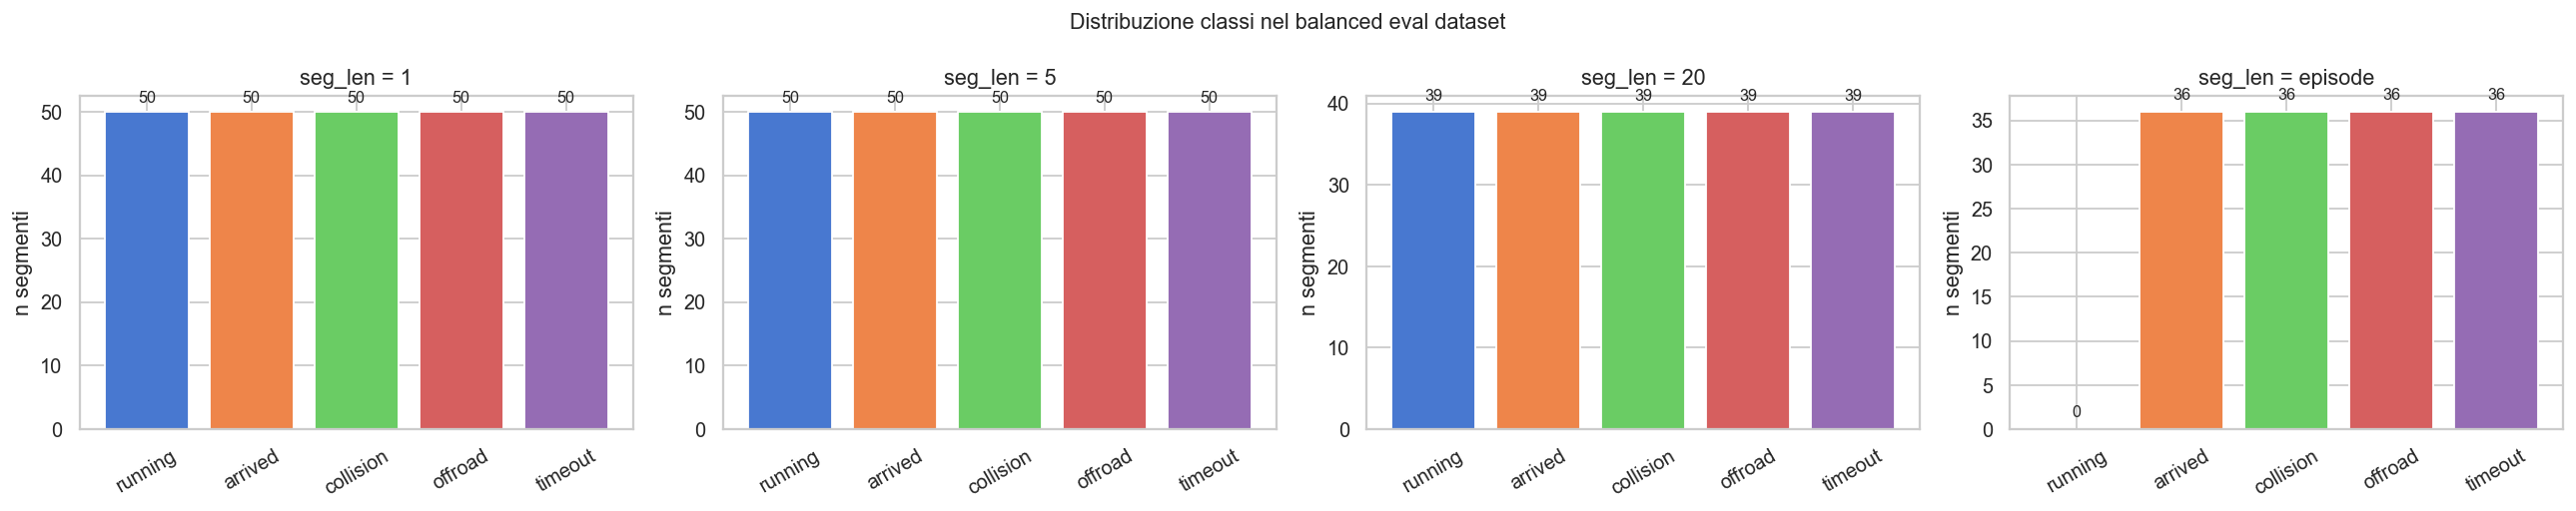


Reward stats per classe (seg_len=1):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
arrived,50.0,20.0000,0.0000,20.0,20.000,20.0000,20.0000,20.0
collision,50.0,-50.0000,0.0000,-50.0,-50.000,-50.0000,-50.0000,-50.0
offroad,50.0,-50.0000,0.0000,-50.0,-50.000,-50.0000,-50.0000,-50.0
running,50.0,0.1495,0.2189,-0.2,-0.003,0.1007,0.2217,0.8
timeout,50.0,0.0000,0.0000,0.0,0.000,0.0000,0.0000,0.0


/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_77486/3175513661.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reward_df, x="label", y="reward", order=order, palette="muted", ax=ax)


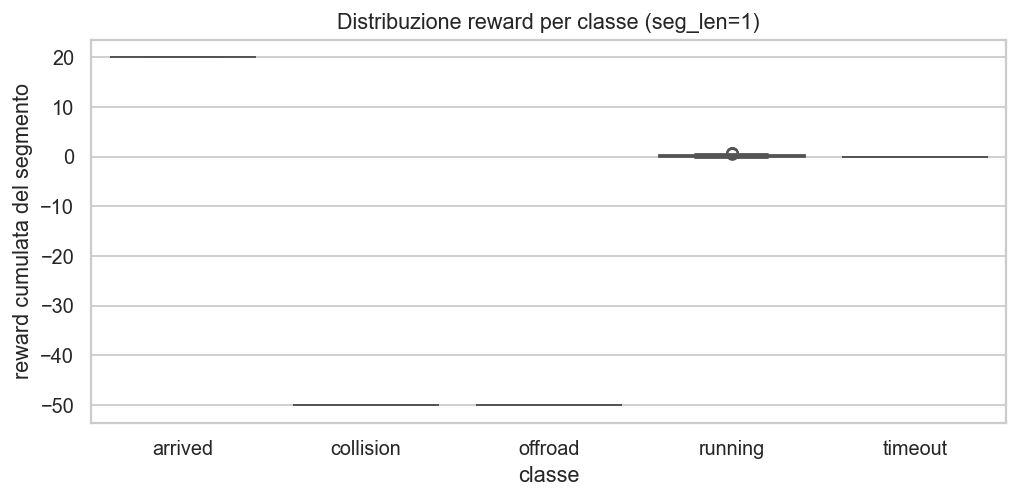


Metadati dataset:
  Creato da   : /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/20260610_092001
  Checkpoint  : checkpoint_0100
  Steps/agent : 30,000
  RNG seed    : 0
  Run usate   : 30


In [6]:
with open(SAVE_PATH, "rb") as f:
    ds = pickle.load(f)

meta = ds["metadata"]
seg_lengths = list(ds["segments_by_length"].keys())

# ── 1. Bilanciamento per classe ─────────────────────────────────────────────
print("=" * 55)
print(f"Classi target : {meta['target_classes']}")
print(f"Segment lengths: {meta['segment_lengths']}")
print(f"N per classe (richiesto): {meta['requested_n_per_class']}")
print(f"N per classe (salvato)  : {meta['actual_n_per_class']}")
print("=" * 55)

balance_rows = []
for seg_len in seg_lengths:
    counts = Counter(ds["labels_by_length"][seg_len])
    row = {"seg_len": seg_len, "tot": sum(counts.values())}
    row.update({cls: counts.get(cls, 0) for cls in meta["target_classes"]})
    balance_rows.append(row)

balance_df = pd.DataFrame(balance_rows).set_index("seg_len")
print("\nConteggi per classe e segment_length:")
display(balance_df)

# ── 2. Bar chart bilanciamento ───────────────────────────────────────────────
classes = meta["target_classes"]
fig, axes = plt.subplots(1, len(seg_lengths), figsize=(5 * len(seg_lengths), 4), squeeze=False)
colors = sns.color_palette("muted", len(classes))

for ax, seg_len in zip(axes.flat, seg_lengths):
    counts = Counter(ds["labels_by_length"][seg_len])
    vals = [counts.get(c, 0) for c in classes]
    bars = ax.bar(classes, vals, color=colors)
    ax.set_title(f"seg_len = {seg_len}")
    ax.set_ylabel("n segmenti")
    ax.tick_params(axis="x", rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
                ha="center", va="bottom", fontsize=9)

fig.suptitle("Distribuzione classi nel balanced eval dataset", fontsize=12)
plt.tight_layout()
plt.show()

# ── 3. Distribuzione reward per classe (seg_len=1) ───────────────────────────
seg_len_for_reward = 1 if 1 in seg_lengths else seg_lengths[0]
segs = ds["segments_by_length"][seg_len_for_reward]
lbls = ds["labels_by_length"][seg_len_for_reward]

reward_data = []
for seg, lbl in zip(segs, lbls):
    r = float(np.sum([t.true_reward for t in seg]))
    reward_data.append({"label": lbl, "reward": r})

reward_df = pd.DataFrame(reward_data)

print(f"\nReward stats per classe (seg_len={seg_len_for_reward}):")
display(reward_df.groupby("label")["reward"].describe().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
order = sorted(reward_df["label"].unique())
sns.boxplot(data=reward_df, x="label", y="reward", order=order, palette="muted", ax=ax)
ax.set_title(f"Distribuzione reward per classe (seg_len={seg_len_for_reward})")
ax.set_xlabel("classe")
ax.set_ylabel("reward cumulata del segmento")
plt.tight_layout()
plt.show()

# ── 4. Lunghezze delle traiettorie sorgente ──────────────────────────────────
print("\nMetadati dataset:")
print(f"  Creato da   : {meta['created_from']}")
print(f"  Checkpoint  : {meta['checkpoint_name']}")
print(f"  Steps/agent : {meta['n_steps_per_agent']:,}")
print(f"  RNG seed    : {meta['rng_seed']}")
print(f"  Run usate   : {len(meta['selected_runs'])}")